# Exploratory Data Analysis

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter

from course_recommender.data.loader import DataLoader

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

## 1. Load Raw Data

In [3]:
loader = DataLoader('../data/raw/CourseraDataset-Unclean.csv')
df = loader.load()
stats = loader.get_statistics()

print(f"Shape: {stats['shape']}")
print(f"Duplicate rows: {stats['duplicate_rows']}")
df.head()

2026-04-18 19:23:02 | INFO     | course_recommender.data.loader | Loading dataset from '../data/raw/CourseraDataset-Unclean.csv'
2026-04-18 19:23:02 | INFO     | course_recommender.data.loader | Loaded 8370 rows x 13 columns (encoding=utf-8)
Shape: (8370, 13)
Duplicate rows: 0


,Course Title,Rating,Level,Schedule,What you will learn,Skill gain,Modules,Instructor,Offered By,Keyword,Course Url,Duration to complete (Approx.),Number of Review
0,Fashion as Design,4.8,Beginner level,Flexible schedule,Not specified,"Art History, Art, History, Creativity","Introduction, Heroes, Silhouettes, Coutures, Lifecycle, Modesty, Expression","Anna Burckhardt, Paola Antonelli, Michelle Millar Fisher, Stephanie Kramer",The Museum of Modern Art,Arts and Humanities,https://www.coursera.org/learn/fashion-design,20.0,2813
1,Modern American Poetry,4.4,Beginner level,Flexible schedule,Not specified,Not specified,"Orientation, Module 1, Module 2, Module 3, Module 4",Cary Nelson,University of Illinois at Urbana-Champaign,Arts and Humanities,https://www.coursera.org/learn/modern-american-poetry,34.0,100
2,Pixel Art for Video Games,4.5,Beginner level,Flexible schedule,Not specified,Not specified,"Week 1: Introduction to Pixel Art, Week 2: Pixel Art Environments, Week 3: Pixel Art Characters,...","Andrew Dennis, Ricardo Guimaraes",Michigan State University,Arts and Humanities,https://www.coursera.org/learn/pixel-art-video-games,9.0,227
3,Distribución digital de la música independiente,0.0,Beginner level,Flexible schedule,Not specified,Not specified,"Semana 1, Semana 2, Semana 3, Semana 4",Eduardo de la Vara Brown.,SAE Institute México,Arts and Humanities,https://www.coursera.org/learn/distribucion-digital-de-la-musica-independiente,8.0,0
4,The Blues: Understanding and Performing an American Art Form,4.8,Beginner level,Flexible schedule,Students will be able to describe the blues as an important musical form. Students will be able ...,"Music, Chord, Jazz, Jazz Improvisation","Blues Progressions – Theory and Practice , Blues Scales , Keyboard Realization , “Bird” Blues an...",Dariusz Terefenko,University of Rochester,Arts and Humanities,https://www.coursera.org/learn/the-blues,11.0,582


## 2. Data Types & Column Overview

In [3]:
print('Column dtypes:')
print(df.dtypes)
print('\nSample values per column:')
for col in df.columns:
    sample = df[col].dropna().head(3).tolist()
    print(f'  {col:40s} → {sample}')

Column dtypes:
Course Title                       object
Rating                            float64
Level                              object
Schedule                           object
What you will learn                object
Skill gain                         object
Modules                            object
Instructor                         object
Offered By                         object
Keyword                            object
Course Url                         object
Duration to complete (Approx.)    float64
Number of Review                    int64
dtype: object

Sample values per column:
  Course Title                             → ['Fashion as Design', 'Modern American Poetry', 'Pixel Art for Video Games']
  Rating                                   → [4.8, 4.4, 4.5]
  Level                                    → ['Beginner level', 'Beginner level', 'Beginner level']
  Schedule                                 → ['Flexible schedule', 'Flexible schedule', 'Flexible schedule']
  What

## 3. Missing Values Analysis

In [4]:
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('pct', ascending=False)

print(missing[missing['count'] > 0].to_string())

fig = px.bar(
    missing[missing['count'] > 0].reset_index(),
    x='index', y='pct',
    title='Missing Values by Column (%)',
    labels={'index': 'Column', 'pct': 'Missing %'},
    color='pct', color_continuous_scale='Reds'
)
fig.update_layout(xaxis_tickangle=-45)
fig.show()

            count   pct
Instructor     88  1.05
Modules        33  0.39


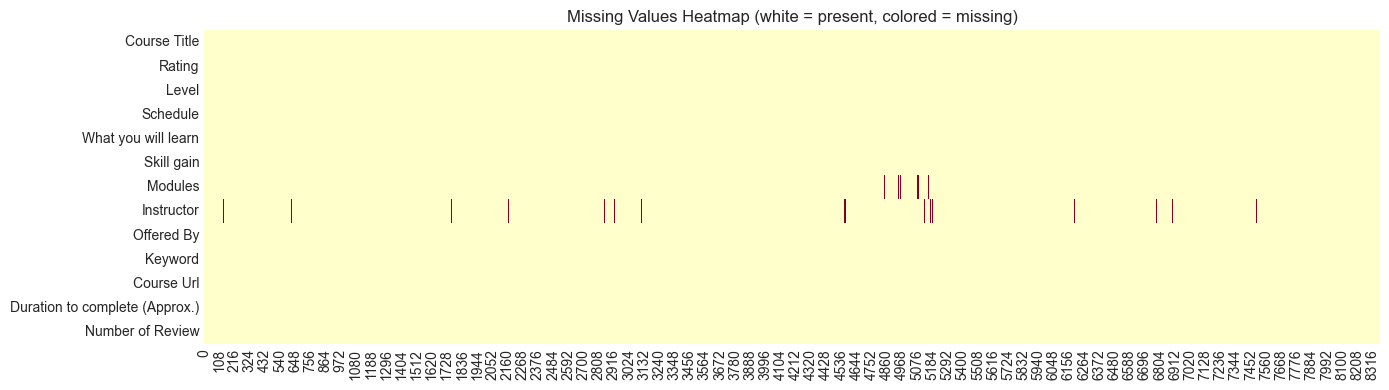

In [5]:
# Missing values heatmap
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df.isnull().T, cbar=False, yticklabels=True, cmap='YlOrRd', ax=ax)
ax.set_title('Missing Values Heatmap (white = present, colored = missing)')
plt.tight_layout()
plt.show()

## 4. Distributions

In [6]:
# Difficulty level distribution
level_col = next((c for c in df.columns if 'difficulty' in c.lower() or c.lower() == 'level'), None)
if level_col:
    level_counts = df[level_col].value_counts()
    fig = px.bar(x=level_counts.index, y=level_counts.values,
                 title=f'{level_col} Distribution',
                 labels={'x': level_col, 'y': 'Count'},
                 color=level_counts.values, color_continuous_scale='Blues')
    fig.show()
else:
    print('No difficulty level column found. Columns:', list(df.columns))

In [7]:
# Rating distribution
rating_col = next((c for c in df.columns if 'rating' in c.lower()), None)
if rating_col:
    ratings = pd.to_numeric(df[rating_col], errors='coerce').dropna()
    fig = px.histogram(x=ratings, nbins=50, title=f'{rating_col} Distribution',
                       labels={'x': rating_col}, marginal='box')
    fig.show()
    print(f'Rating stats: min={ratings.min():.2f}, max={ratings.max():.2f}, mean={ratings.mean():.2f}')

Rating stats: min=0.00, max=5.00, mean=4.01


In [8]:
# Top 20 universities
uni_col = next((c for c in df.columns if 'university' in c.lower() or 'organization' in c.lower()), None)
if uni_col:
    top_unis = df[uni_col].value_counts().head(20)
    fig = px.bar(x=top_unis.values, y=top_unis.index, orientation='h',
                 title=f'Top 20 {uni_col}s',
                 labels={'x': 'Course Count', 'y': uni_col})
    fig.update_layout(height=600)
    fig.show()

## 5. Text Analysis

In [9]:
# Description length distribution
desc_col = next((c for c in df.columns if 'description' in c.lower() or 'about' in c.lower()), None)
if desc_col:
    desc_lens = df[desc_col].fillna('').astype(str).str.len()
    fig = px.histogram(x=desc_lens, nbins=80, title='Course Description Length Distribution',
                       labels={'x': 'Character Length'})
    fig.show()
    print(f'Description length: mean={desc_lens.mean():.0f}, median={desc_lens.median():.0f}, max={desc_lens.max()}')

In [10]:
# Top skills
skills_col = next((c for c in df.columns if 'skill' in c.lower()), None)
if skills_col:
    all_skills = []
    for s in df[skills_col].dropna().astype(str):
        all_skills.extend([x.strip() for x in s.split(',') if x.strip()])
    top_skills = Counter(all_skills).most_common(30)
    skills_df = pd.DataFrame(top_skills, columns=['Skill', 'Count'])
    fig = px.bar(skills_df, x='Count', y='Skill', orientation='h',
                 title='Top 30 Skills Taught',
                 color='Count', color_continuous_scale='Viridis')
    fig.update_layout(height=800, yaxis={'categoryorder': 'total ascending'})
    fig.show()

## 6. Data Quality Issues Summary

In [11]:
url_col = next((c for c in df.columns if 'url' in c.lower()), None)
name_col = next((c for c in df.columns if 'name' in c.lower() or 'title' in c.lower()), None)

issues = {}
if url_col:
    issues['Duplicate URLs'] = int(df[url_col].dropna().duplicated().sum())
if name_col:
    issues['Duplicate Names'] = int(df[name_col].dropna().duplicated().sum())
if rating_col:
    r = pd.to_numeric(df[rating_col], errors='coerce')
    issues['Invalid Ratings (out of 0-5)'] = int(((r < 0) | (r > 5)).sum())

for col in df.columns:
    pct = df[col].isnull().mean() * 100
    if pct > 0:
        issues[f'Missing: {col}'] = f'{pct:.1f}%'

print('=== Data Quality Issues Found ===')
for k, v in issues.items():
    print(f'  {k}: {v}')

print('\n=== Recommended Cleaning Strategy ===')
print('1. Remove duplicates by URL, then by Name+University')
print('2. Drop rows with missing Course Name or Course URL')
print('3. Fill missing descriptions/skills with empty strings')
print('4. Filter ratings to [0, 5] range')
print('5. Standardize difficulty level labels')
print('6. Create combined_text feature for embeddings')

=== Data Quality Issues Found ===
  Duplicate URLs: 2277
  Duplicate Names: 2289
  Invalid Ratings (out of 0-5): 0
  Missing: Modules: 0.4%
  Missing: Instructor: 1.1%

=== Recommended Cleaning Strategy ===
1. Remove duplicates by URL, then by Name+University
2. Drop rows with missing Course Name or Course URL
3. Fill missing descriptions/skills with empty strings
4. Filter ratings to [0, 5] range
5. Standardize difficulty level labels
6. Create combined_text feature for embeddings
